<a href="https://colab.research.google.com/github/Sitthisak17SM/Super_AI/blob/main/House_Recognition_600817.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os, csv, re, time, requests
import numpy as np
import pandas as pd
from pathlib import Path
from google.colab import userdata

# Data

KAGGLE_API_KEY = userdata.get('KAGGLE_API')
os.environ['KAGGLE_API_TOKEN'] = KAGGLE_API_KEY
!kaggle competitions download -c super-ai-engineer-season-6-individual-hackathon-house-recognition
!unzip -q super-ai-engineer-season-6-individual-hackathon-house-recognition

100% 1.25G/1.25G [00:11<00:00, 119MB/s]



In [ ]:
import os, matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image

# path จริงตาม folder structure ที่เห็น
TRAIN_DIR = Path("train/train")
TEST_DIR  = Path("test/test")
LABEL_CSV = Path("train.csv")        # ไม่ใช่ train_labels.csv

# ตรวจว่า path มีจริงก่อน
for p in [TRAIN_DIR, TEST_DIR, LABEL_CSV]:
    status = "✓" if p.exists() else "✗ NOT FOUND"
    print(f"{status}  {p}")

df = pd.read_csv(LABEL_CSV)
print("\n--- head ---")
print(df.head())
print(f"\nShape : {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print("\n--- class distribution ---")
print(df.iloc[:, -1].value_counts())   # ใช้ iloc เผื่อชื่อ col ต่างออกไป

✓  train/train
✓  test/test
✓  train.csv

--- head ---
                                          image_name  class
0  ChokChai4_img_13-7956791_100-6031267_a187-2159...      0
1  ChokChai4_img_13-7961753_100-6031881_a185-9785...      0
2  ChokChai4_img_13-7969811_100-5906061_a180-5812...      0
3  ChokChai4_img_13-7970811_100-5906071_a180-5812...      0
4  ChokChai4_img_13-7971811_100-5906081_a180-5812...      0

Shape : (2953, 2)
Columns: ['image_name', 'class']

--- class distribution ---
class
0    1520
1    1433
Name: count, dtype: int64


In [ ]:
# รันอันนี้ก่อนเพื่อดูชื่อ column จริง แล้วค่อยแก้ไปใช้ชื่อนั้น
df = pd.read_csv("train.csv")
print(df.head(3))
print(df.columns.tolist())

# หลังจากได้ชื่อ column แล้ว ค่อยใส่ชื่อจริงตรงนี้
ID_COL     = df.columns[0]   # คาดว่าเป็น "id"
LABEL_COL  = df.columns[1]   # คาดว่าเป็น "answer"

print(f"\nClass distribution:")
print(df[LABEL_COL].value_counts())
print(f"\nClass ratio: {df[LABEL_COL].value_counts(normalize=True).round(3).to_dict()}")

                                          image_name  class
0  ChokChai4_img_13-7956791_100-6031267_a187-2159...      0
1  ChokChai4_img_13-7961753_100-6031881_a185-9785...      0
2  ChokChai4_img_13-7969811_100-5906061_a180-5812...      0
['image_name', 'class']

Class distribution:
class
0    1520
1    1433
Name: count, dtype: int64

Class ratio: {0: 0.515, 1: 0.485}


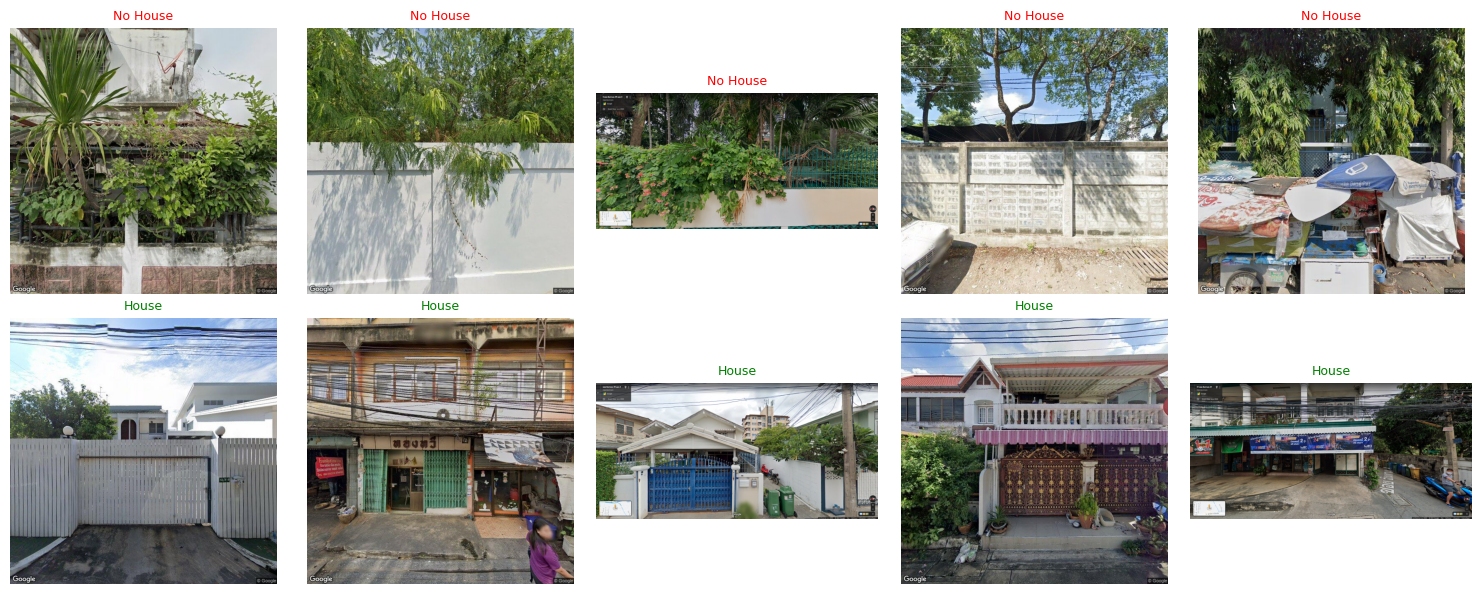

In [ ]:
# แสดงตัวอย่าง 5 รูปต่อ class
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

# ใช้ชื่อ column ที่ถูกต้องจาก data ของคุณ
# ID_COL = 'image_name', LABEL_COL = 'class'

for label in [0, 1]:
    samples = df[df[LABEL_COL] == label].sample(5, random_state=42)
    for i, (_, row) in enumerate(samples.iterrows()):
        # image_name ใน CSV อาจจะมีหรือไม่มี .jpg มาให้
        img_name = str(row[ID_COL])
        if not img_name.endswith('.jpg'):
            img_name += '.jpg'

        img_path = TRAIN_DIR / img_name
        img = Image.open(img_path)
        axes[label][i].imshow(img)
        axes[label][i].set_title(f"{'No House' if label==0 else 'House'}",
                           fontsize=9, color='red' if label==0 else 'green')
        axes[label][i].axis('off')

plt.tight_layout()
plt.show()

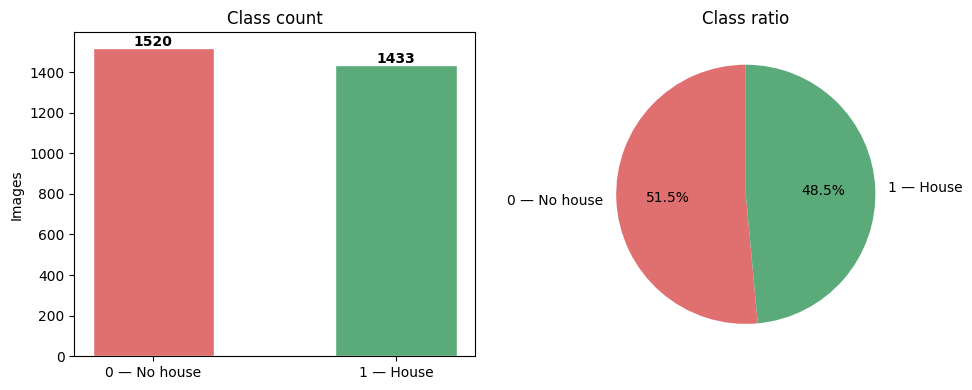

Imbalance ratio: 1.06x


In [ ]:
counts = df[LABEL_COL].value_counts().sort_index()
labels = ["0 — No house", "1 — House"]
colors = ["#e07070", "#5aaa7a"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# bar chart
ax1.bar(labels, counts.values, color=colors, edgecolor="white", width=0.5)
ax1.set_title("Class count")
ax1.set_ylabel("Images")
for i, v in enumerate(counts.values):
    ax1.text(i, v + 10, str(v), ha="center", fontweight="bold")

# pie chart
ax2.pie(counts.values, labels=labels, colors=colors,
       autopct="%1.1f%%", startangle=90)
ax2.set_title("Class ratio")

plt.tight_layout()
plt.show()
print(f"Imbalance ratio: {counts.max()/counts.min():.2f}x")

Width  — min:640  max:1920  mean:768
Height — min:640  max:925  mean:669
Aspect — min:1.00  max:2.08  mean:1.11


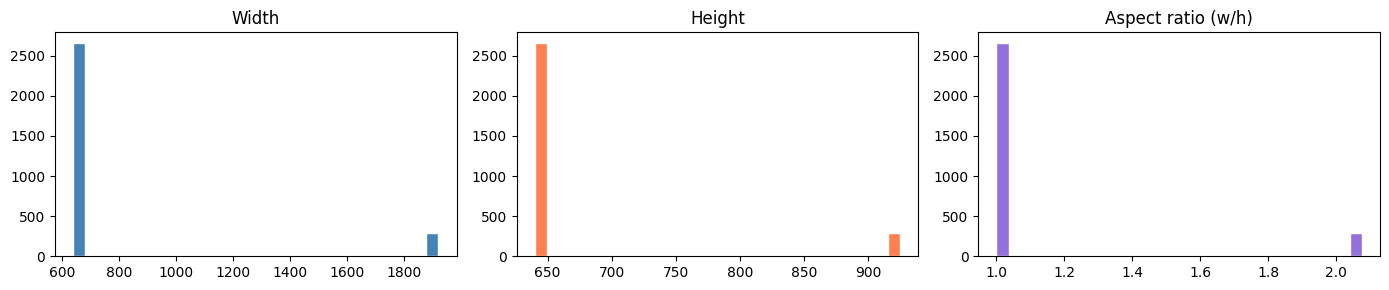

In [ ]:
widths, heights, aspect_ratios = [], [], []

for img_id in df[ID_COL]:
    # Check if .jpg is already in the name to avoid double extensions
    img_name = str(img_id)
    if not img_name.lower().endswith('.jpg'):
        img_name += '.jpg'

    img_path = TRAIN_DIR / img_name
    with Image.open(img_path) as img:
        w, h = img.size
        widths.append(w)
        heights.append(h)
        aspect_ratios.append(w / h)

print(f"Width  — min:{min(widths)}  max:{max(widths)}  mean:{np.mean(widths):.0f}")
print(f"Height — min:{min(heights)}  max:{max(heights)}  mean:{np.mean(heights):.0f}")
print(f"Aspect — min:{min(aspect_ratios):.2f}  max:{max(aspect_ratios):.2f}  mean:{np.mean(aspect_ratios):.2f}")

fig, axes = plt.subplots(1, 3, figsize=(14, 3))
for ax, data, title, color in zip(axes,
        [widths, heights, aspect_ratios],
        ["Width", "Height", "Aspect ratio (w/h)"],
        ["steelblue", "coral", "mediumpurple"]):
    ax.hist(data, bins=30, color=color, edgecolor="white")
    ax.set_title(title)

plt.tight_layout()
plt.show()

In [ ]:
bad_files = []

for img_id in df[ID_COL]:
    img_path = TRAIN_DIR / f"{img_id}"
    try:
        with Image.open(img_path) as img:
            img.verify()
    except Exception as e:
        bad_files.append((img_id, str(e)))

print(f"Corrupted files: {len(bad_files)} / {len(df)}")
if bad_files:
    print(bad_files)

Corrupted files: 0 / 2953


  0%|          | 0/2953 [00:00<?, ?it/s]

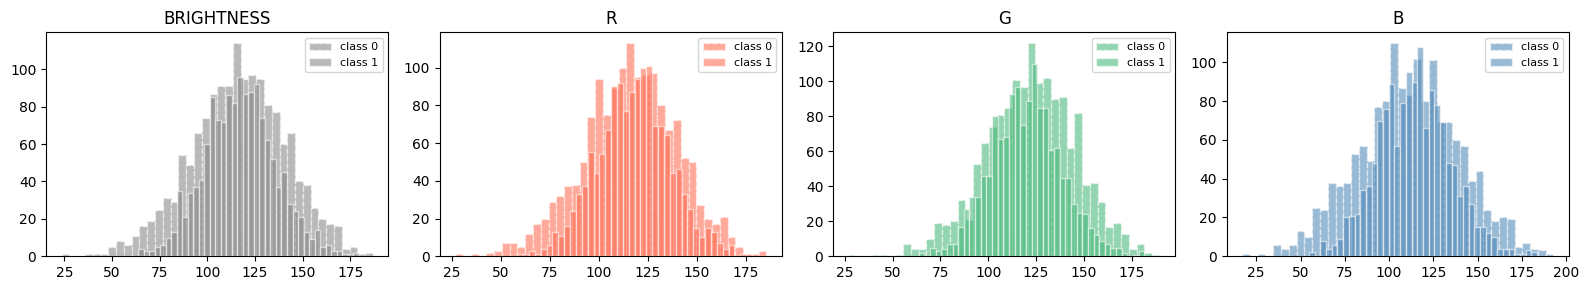

       brightness           r           g           b
label                                                
0      116.360001  115.709999  122.230003  111.129997
1      117.239998  117.779999  119.730003  114.209999


In [ ]:
from tqdm.notebook import tqdm

stats = {"id": [], "label": [], "brightness": [], "r": [], "g": [], "b": []}

for _, row in tqdm(df.iterrows(), total=len(df)):
    # image_name already contains .jpg, so we don't add it manually
    img_name = str(row[ID_COL])
    img_path = TRAIN_DIR / img_name

    try:
        img = Image.open(img_path).convert("RGB")
        arr = np.array(img, dtype=np.float32)
        stats["id"].append(row[ID_COL])
        stats["label"].append(row[LABEL_COL])
        stats["brightness"].append(arr.mean())
        stats["r"].append(arr[..., 0].mean())
        stats["g"].append(arr[..., 1].mean())
        stats["b"].append(arr[..., 2].mean())
    except FileNotFoundError:
        # Fallback in case some rows don't have the extension
        img_path = TRAIN_DIR / f"{img_name}.jpg"
        img = Image.open(img_path).convert("RGB")
        arr = np.array(img, dtype=np.float32)
        stats["id"].append(row[ID_COL])
        stats["label"].append(row[LABEL_COL])
        stats["brightness"].append(arr.mean())
        stats["r"].append(arr[..., 0].mean())
        stats["g"].append(arr[..., 1].mean())
        stats["b"].append(arr[..., 2].mean())

stat_df = pd.DataFrame(stats)

fig, axes = plt.subplots(1, 4, figsize=(16, 3))
for ax, col, color in zip(axes,
        ["brightness", "r", "g", "b"],
        ["gray", "tomato", "mediumseagreen", "steelblue"]):
    for lbl, ls in [(0, "--"), (1, "-")]:
        subset = stat_df[stat_df["label"] == lbl][col]
        ax.hist(subset, bins=40, alpha=0.55, color=color,
               linestyle=ls, label=f"class {lbl}", edgecolor="white")
    ax.set_title(col.upper())
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# Summary averages per class
print(stat_df.groupby("label")[["brightness","r","g","b"]].mean().round(2))

## Image Dimensions

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.model_selection import train_test_split

# กำหนดค่ามาตรฐานของ ImageNet สำหรับการ Normalize
stats = ([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])

train_transform = transforms.Compose([
    # 1. Resize ด้านที่ยาวที่สุดให้เป็น 224 โดยรักษาอัตราส่วนเดิม
    transforms.Resize(224),
    # 2. Crop ตรงกลางให้ได้ 224x224 (ถ้ากว้างเกินไปส่วนขอบจะหายเล็กน้อย)
    # หรือใช้ transforms.CenterCrop(224)
    transforms.CenterCrop(224),
    # 3. Data Augmentation (ช่วยให้ Model ฉลาดขึ้น)
    transforms.RandomHorizontalFlip(p=0.5), # พลิกซ้ายขวา (บ้านยังเป็นบ้าน)
    transforms.ColorJitter(brightness=0.2, contrast=0.2), # ปรับแสงเล็กน้อย
    transforms.ToTensor(),
    transforms.Normalize(*stats)
])

val_transform = transforms.Compose([
    transforms.Resize(224),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(*stats)
])

In [ ]:
class HouseDataset(Dataset):
    def __init__(self, dataframe, root_dir, transform=None):
        self.df = dataframe
        self.root_dir = Path(root_dir)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # ดึงชื่อไฟล์และ Label
        img_name = str(self.df.iloc[idx, 0])
        if not img_name.lower().endswith('.jpg'):
            img_name += '.jpg'

        label = self.df.iloc[idx, 1]
        img_path = self.root_dir / img_name

        # โหลดรูป
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.long)

# 1. แบ่งข้อมูลเป็น Train 80% และ Validation 20%
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df[LABEL_COL])

# 2. สร้าง Dataset object
train_ds = HouseDataset(train_df, TRAIN_DIR, transform=train_transform)
val_ds = HouseDataset(val_df, TRAIN_DIR, transform=val_transform)

# 3. สร้าง DataLoader (ตัวส่งข้อมูลเข้า AI)
batch_size = 32
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=2)

print(f"Train samples: {len(train_ds)} | Val samples: {len(val_ds)}")

Train samples: 2362 | Val samples: 591


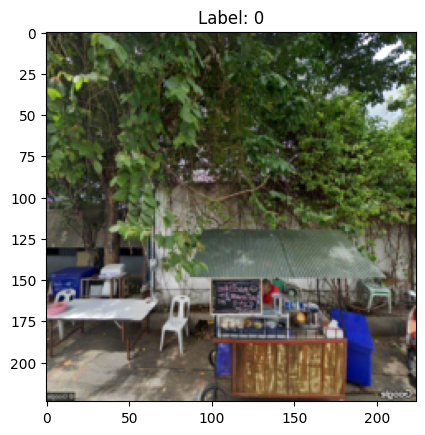

In [ ]:
import matplotlib.pyplot as plt

# ดึงข้อมูลมา 1 Batch
images, labels = next(iter(train_loader))

# แสดงผลรูปแรก
plt.imshow(images[0].permute(1, 2, 0).numpy() * stats[1] + stats[0]) # Un-normalize เพื่อดูสีจริง
plt.title(f"Label: {labels[0].item()}")
plt.show()

In [ ]:
# import torch
# import torch.nn as nn
# from torchvision import models

# # 1. โหลด EfficientNet-B3 พร้อมน้ำหนักที่ฝึกมาแล้ว
# model = models.efficientnet_b3(weights='DEFAULT')

# # 2. ปรับเปลี่ยน Classifier
# # ใน B3, ส่วน classifier จะเป็น Sequential ที่มี Dropout และ Linear
# # เราต้องดูว่า in_features ของตัวเดิมคือเท่าไหร่ (สำหรับ B3 คือ 1536)
# num_ftrs = model.classifier[1].in_features
# model.classifier[1] = nn.Linear(num_ftrs, 2) # เปลี่ยนเป็น 2 classes

# # 3. ส่งไปที่ GPU
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# model = model.to(device)

# print(f"ใช้โมเดล: EfficientNet-B3")
# print(f"อุปกรณ์ที่ใช้: {device}")

ใช้โมเดล: EfficientNet-B3
อุปกรณ์ที่ใช้: cuda


In [ ]:
import torch.nn as nn
from torchvision import models

print("🔥 เปลี่ยนอาวุธ: โหลดโมเดล ConvNeXt-Tiny...")

# 1. โหลด Pre-trained Model
model = models.convnext_tiny(weights='DEFAULT')

# 2. ปรับส่วน Classifier ให้เหลือ 2 Class
# ConvNeXt มีโครงสร้าง Classifier ตำแหน่งที่ 2 เป็น nn.Linear
num_ftrs = model.classifier[2].in_features
model.classifier[2] = nn.Linear(num_ftrs, 2)

# 3. ส่งไปที่ GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# model = model.to(device)

# print(f"ใช้โมเดล: EfficientNet-B3")
# print(f"อุปกรณ์ที่ใช้: {device}")
model = model.to(device)

print(f"เตรียม ConvNeXt สำเร็จ! (in_features = {num_ftrs})")

🔥 เปลี่ยนอาวุธ: โหลดโมเดล ConvNeXt-Tiny...
เตรียม ConvNeXt สำเร็จ! (in_features = 768)


In [ ]:
import torch.optim as optim

# ใช้ AdamW แทน Adam (เหมาะกับ ConvNeXt มากกว่า)
optimizer = optim.AdamW(model.parameters(), lr=2e-4, weight_decay=1e-2)

# ใส่ Label Smoothing 0.05 เหมือนเดิมเพื่อกัน Overfit
criterion = nn.CrossEntropyLoss(label_smoothing=0.05)

In [ ]:
# import torch.optim as optim

# # Loss Function: สำหรับแยก 2 คลาส
# criterion = nn.CrossEntropyLoss(label_smoothing=0.05)

# # Optimizer: Adam เป็นมาตรฐานที่ทำงานได้ดีมาก
# optimizer = optim.Adam(model.parameters(), lr=1e-4) # เริ่มต้นที่ lr น้อยๆ เพื่อไม่ให้ลืมความรู้เก่า

# # Scheduler: ลดความเร็วในการเรียนรู้ลง 10 เท่า ทุกๆ 5 รอบ (Epoch)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

In [ ]:
def train_model(model, criterion, optimizer, scheduler, num_epochs=10):
    for epoch in range(num_epochs):
        model.train() # ตั้งโหมดเทรน
        running_loss = 0.0
        correct = 0
        total = 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            # ล้างค่า Gradient
            optimizer.zero_grad()

            # Forward: ให้โมเดลทาย
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            # Backward: คำนวณ Error และปรับค่าน้ำหนัก
            loss.backward()
            optimizer.step()

            # เก็บสถิติ
            running_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        epoch_loss = running_loss / len(train_loader.dataset)
        epoch_acc = 100. * correct / total

        # ปรับ LR
        scheduler.step()

        print(f'Epoch {epoch+1}/{num_epochs} | Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.2f}%')

# เริ่มเทรน! (ลอง 10 รอบก่อน)
train_model(model, criterion, optimizer, scheduler, num_epochs=10)

Epoch 1/10 | Loss: 0.1609 | Acc: 98.05%
Epoch 2/10 | Loss: 0.1434 | Acc: 98.73%
Epoch 3/10 | Loss: 0.1458 | Acc: 98.77%
Epoch 4/10 | Loss: 0.1259 | Acc: 99.70%
Epoch 5/10 | Loss: 0.1221 | Acc: 99.92%
Epoch 6/10 | Loss: 0.1202 | Acc: 99.96%
Epoch 7/10 | Loss: 0.1196 | Acc: 99.96%
Epoch 8/10 | Loss: 0.1187 | Acc: 100.00%
Epoch 9/10 | Loss: 0.1184 | Acc: 100.00%
Epoch 10/10 | Loss: 0.1184 | Acc: 100.00%


In [ ]:
def evaluate_model(model, dataloader):
    model.eval() # เปลี่ยนเป็นโหมดทดสอบ (ปิด Dropout/BatchNorm)
    correct = 0
    total = 0

    with torch.no_grad(): # ปิดการคำนวณ Gradient เพื่อประหยัดเมมโมรี่และทำงานเร็วขึ้น
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            _, predicted = outputs.max(1)

            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    val_acc = 100. * correct / total
    print(f'✨ Validation Accuracy: {val_acc:.2f}% ✨')

# เรียกใช้งานฟังก์ชัน
evaluate_model(model, val_loader)

✨ Validation Accuracy: 96.45% ✨


In [ ]:
# บันทึกเฉพาะ "น้ำหนักความรู้ (Weights)" ของโมเดล
torch.save(model.state_dict(), 'efficientnet_b3_house_model.pth')
print("เซฟโมเดลสำเร็จ! ไฟล์ชื่อ 'efficientnet_b3_house_model.pth'")

เซฟโมเดลสำเร็จ! ไฟล์ชื่อ 'efficientnet_b3_house_model.pth'


In [ ]:
import os
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from tqdm.notebook import tqdm

# 1. เตรียม Data Pipeline สำหรับชุดทดสอบ (เหมือน Validation เป๊ะ ห้ามทำ Augmentation)
stats = ([0.485, 0.456, 0.406], [0.229, 0.244, 0.225])
test_transform = transforms.Compose([
    transforms.Resize(224),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(*stats)
])

# 2. สร้าง Custom Dataset สำหรับ Test
class TestDataset(Dataset):
    def __init__(self, test_dir, transform=None):
        self.test_dir = Path(test_dir)
        self.transform = transform
        # ดึงรายชื่อไฟล์ทั้งหมดในโฟลเดอร์ test (เฉพาะไฟล์ .jpg หรือ .png)
        self.image_files = [f for f in os.listdir(self.test_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        # เรียงลำดับชื่อไฟล์ (สำคัญมาก เพื่อให้ส่งคำตอบตรงกับที่ระบบ Kaggle ตรวจ)
        self.image_files.sort()

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_name = self.image_files[idx]
        img_path = self.test_dir / img_name

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        # ส่งคืนรูปภาพ และ ชื่อไฟล์ (ตัดนามสกุลออก ถ้า Kaggle ต้องการแค่ชื่อ ID)
        img_id = os.path.splitext(img_name)[0]

        return image, img_id

# 3. สร้าง Test DataLoader
test_ds = TestDataset(TEST_DIR, transform=test_transform)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=2)

print(f"เตรียมทำนายภาพทั้งหมด: {len(test_ds)} รูป")

# 4. เริ่มขั้นตอนการทำนาย (Inference)
model.eval() # ปิดโหมดเทรน
predictions = []
image_ids = []

print("กำลังทำนายผล...")
with torch.no_grad(): # ปิดการจำ Gradient เพื่อความรวดเร็วและประหยัด RAM
    for inputs, img_id in tqdm(test_loader):
        inputs = inputs.to(device)

        # ให้โมเดลเดา
        outputs = model(inputs)

        # เลือกคลาสที่มีความน่าจะเป็นสูงสุด (0 หรือ 1)
        _, preds = outputs.max(1)

        predictions.extend(preds.cpu().numpy())
        image_ids.extend(img_id)

# 5. สร้างไฟล์ CSV สำหรับส่ง Kaggle
# *หมายเหตุ: ตรวจสอบชื่อคอลัมน์จากไฟล์ sample_submission.csv ของการแข่งขันอีกครั้ง
# สมมติว่า Kaggle ใช้คอลัมน์ชื่อ 'id' และ 'answer'
submission_df = pd.DataFrame({
    'id': image_ids,
    'answer': predictions # หรือเปลี่ยนเป็นชื่อคอลัมน์ LABEL_COL ที่คุณตั้งไว้
})

# ตรวจสอบ Format ก่อนเซฟ
print("\nตัวอย่างผลลัพธ์:")
print(submission_df.head())

# เซฟเป็นไฟล์ CSV
submission_df.to_csv('submission.csv', index=False)
print("\n✅ สร้างไฟล์ 'submission.csv' ")

เตรียมทำนายภาพทั้งหมด: 1550 รูป
กำลังทำนายผล...


  0%|          | 0/49 [00:00<?, ?it/s]


ตัวอย่างผลลัพธ์:
         id  answer
0  00162f19       0
1  004c4789       0
2  0059b42f       1
3  005f930c       0
4  009095e8       1

✅ สร้างไฟล์ 'submission.csv' สำเร็จ! สามารถนำไปส่งในระบบ Kaggle ได้เลยครับ
